# Module 2 — Regression Analysis
### NASA PSCompPars Exoplanet Dataset
**Part A:** Planet Mass–Radius power-law relation  
**Part B:** Multiple linear regression — stellar properties → planet radius

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='darkgrid', palette='muted')
OUT_DIR = Path('regression_output')
OUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(
    Path.home() / 'Downloads' / 'PSCompPars_2026.06.30_11.22.37.csv',
    comment='#', low_memory=False
)
print(f'Loaded {len(df):,} planets')

Loaded 6,298 planets


---
## Part A — Mass–Radius Power Law
We work in log₁₀ space so the power-law `R ∝ M^α` becomes a straight line: `log R = α·log M + c`

In [2]:
# Keep only rows with valid, positive mass and radius
mr = df[['pl_bmasse', 'pl_rade', 'discoverymethod']].dropna()
mr = mr[(mr['pl_bmasse'] > 0) & (mr['pl_rade'] > 0)]

log_mass   = np.log10(mr['pl_bmasse'])
log_radius = np.log10(mr['pl_rade'])

# Fit linear regression in log-log space
model_mr = LinearRegression()
model_mr.fit(log_mass.values.reshape(-1, 1), log_radius.values)
alpha = model_mr.coef_[0]
c     = model_mr.intercept_
r2    = r2_score(log_radius, model_mr.predict(log_mass.values.reshape(-1, 1)))

print(f'Power-law exponent  α = {alpha:.3f}')
print(f'Intercept           c = {c:.3f}')
print(f'R²                    = {r2:.3f}')
print(f'\nFitted relation: log₁₀(R) = {alpha:.3f} · log₁₀(M) + {c:.3f}')
print(f'i.e.  R ∝ M^{alpha:.3f}')

Power-law exponent  α = 0.355
Intercept           c = 0.092
R²                    = 0.843

Fitted relation: log₁₀(R) = 0.355 · log₁₀(M) + 0.092
i.e.  R ∝ M^0.355


/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/976208722.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/976208722.py:40: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/976208722.py:40: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/976208722.py:41: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / 'A_mass_radius.png', dpi=150, bbox_inches='tight')
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/976208722.py:41: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / 'A_mass_radius.png', dpi=150, bbox_inches='tight')
/var/folders/s4/

/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


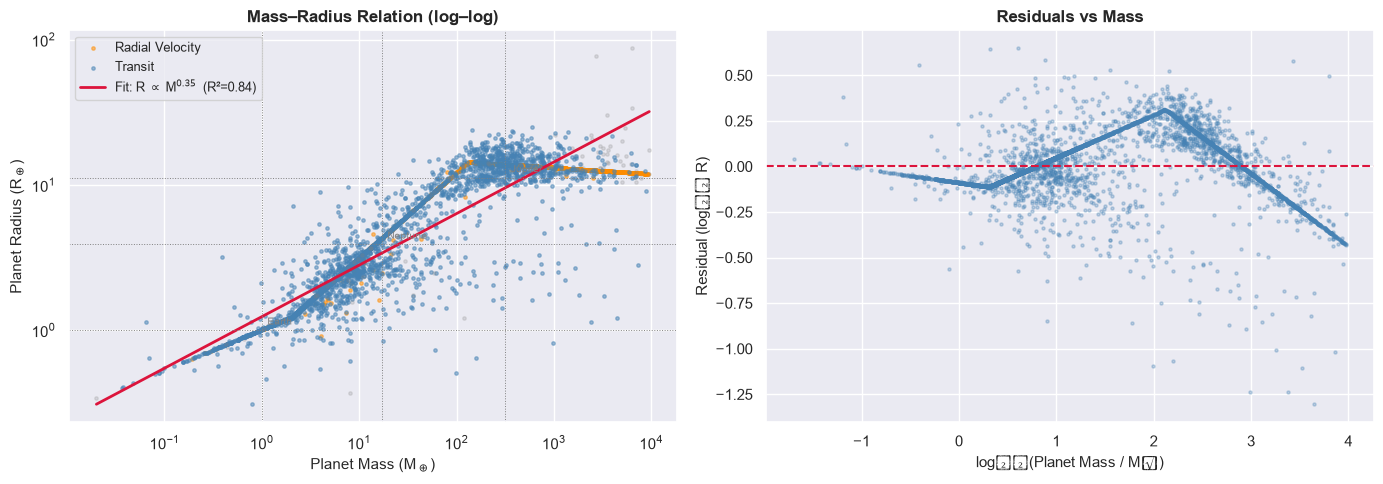

Saved A_mass_radius.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter + fit line ──
ax = axes[0]
colors = {'Transit': 'steelblue', 'Radial Velocity': 'darkorange'}
for method, grp in mr.groupby('discoverymethod'):
    col = colors.get(method, 'gray')
    alpha_pt = 0.5 if method in colors else 0.2
    ax.scatter(grp['pl_bmasse'], grp['pl_rade'],
               s=6, alpha=alpha_pt, color=col,
               label=method if method in colors else '_nolegend_')

x_line = np.logspace(log_mass.min(), log_mass.max(), 300)
y_line = 10 ** (alpha * np.log10(x_line) + c)
ax.plot(x_line, y_line, color='crimson', linewidth=2,
        label=f'Fit: R $\\propto$ M$^{{{alpha:.2f}}}$  (R²={r2:.2f})')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Planet Mass (M$_\\oplus$)', fontsize=11)
ax.set_ylabel('Planet Radius (R$_\\oplus$)', fontsize=11)
ax.set_title('Mass–Radius Relation (log–log)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Reference lines
for mass, radius, label in [(1,1,'Earth'), (17.1,3.9,'Neptune'), (317.8,11.2,'Jupiter')]:
    ax.axvline(mass, color='gray', linewidth=0.7, linestyle=':')
    ax.axhline(radius, color='gray', linewidth=0.7, linestyle=':')
    ax.annotate(label, xy=(mass, radius), xytext=(4,4),
                textcoords='offset points', fontsize=7, color='gray')

# ── Residuals ──
ax2 = axes[1]
residuals = log_radius.values - model_mr.predict(log_mass.values.reshape(-1, 1))
ax2.scatter(log_mass, residuals, s=5, alpha=0.3, color='steelblue')
ax2.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
ax2.set_xlabel('log₁₀(Planet Mass / M⊕)', fontsize=11)
ax2.set_ylabel('Residual (log₁₀ R)', fontsize=11)
ax2.set_title('Residuals vs Mass', fontsize=12, fontweight='bold')

fig.tight_layout()
fig.savefig(OUT_DIR / 'A_mass_radius.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved A_mass_radius.png')

---
## Part B — Multiple Linear Regression: Stellar → Planet Radius
Predictors: stellar temperature, stellar radius, stellar mass  
Target: planet radius (log₁₀ scale)

In [4]:
FEATURES = ['st_teff', 'st_rad', 'st_mass']
TARGET   = 'pl_rade'

reg = df[FEATURES + [TARGET]].dropna()
reg = reg[reg[TARGET] > 0]

# Log-scale skewed columns
X = reg[FEATURES].copy()
X['st_rad']  = np.log10(X['st_rad'])
X['st_mass'] = np.log10(X['st_mass'])
y = np.log10(reg[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model_stellar = LinearRegression()
model_stellar.fit(X_train_s, y_train)

y_pred = model_stellar.predict(X_test_s)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Test R²  = {r2:.3f}')
print(f'Test MAE = {mae:.3f} (in log₁₀ R⊕ units)\n')

coef_df = pd.DataFrame({
    'Feature':     ['st_teff', 'log st_rad', 'log st_mass'],
    'Coefficient': model_stellar.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('Standardised coefficients (larger |value| = stronger predictor):')
print(coef_df.to_string(index=False))

Test R²  = 0.197
Test MAE = 0.302 (in log₁₀ R⊕ units)

Standardised coefficients (larger |value| = stronger predictor):
    Feature  Coefficient
 log st_rad     0.161919
    st_teff     0.031630
log st_mass    -0.008323


/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/3896789792.py:21: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/3896789792.py:21: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/3896789792.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / 'B_stellar_regression.png', dpi=150, bbox_inches='tight')
/var/folders/s4/202ppdt12sqbczv27mz_z5hw0000gn/T/ipykernel_33493/3896789792.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(OUT_DIR / 'B_stellar_regression.png', dpi=150, bbox_inches='tight')


/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


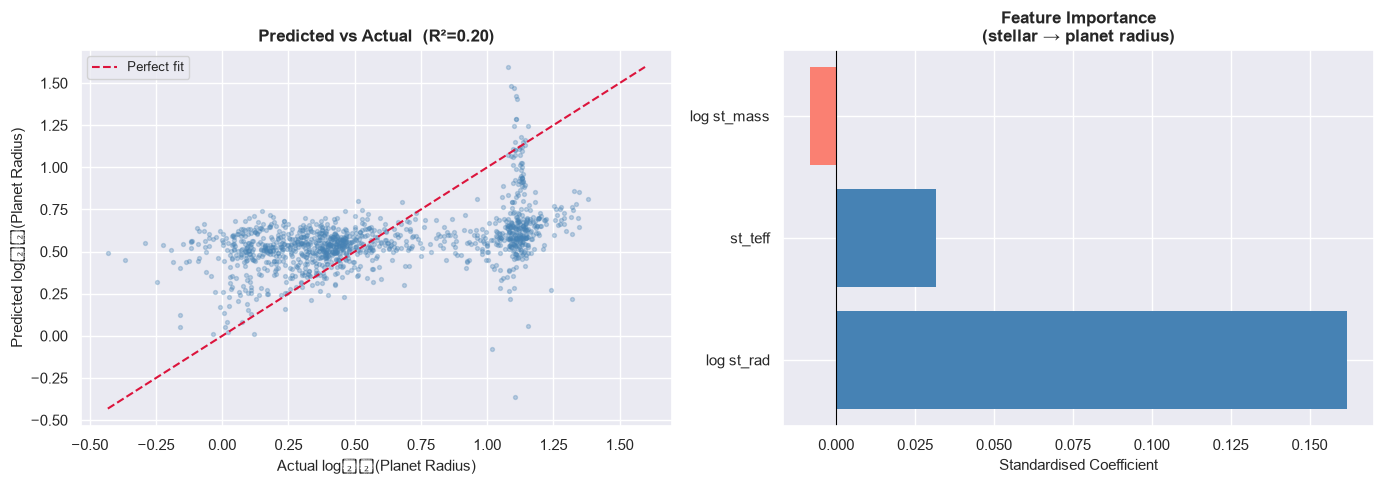

Saved B_stellar_regression.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Predicted vs Actual ──
ax = axes[0]
ax.scatter(y_test, y_pred, s=8, alpha=0.3, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color='crimson', linewidth=1.5, linestyle='--', label='Perfect fit')
ax.set_xlabel('Actual log₁₀(Planet Radius)', fontsize=11)
ax.set_ylabel('Predicted log₁₀(Planet Radius)', fontsize=11)
ax.set_title(f'Predicted vs Actual  (R²={r2:.2f})', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# ── Coefficient Bar Chart ──
ax2 = axes[1]
bar_colors = ['steelblue' if v >= 0 else 'salmon' for v in coef_df['Coefficient']]
ax2.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, edgecolor='none')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Standardised Coefficient', fontsize=11)
ax2.set_title('Feature Importance\n(stellar → planet radius)', fontsize=12, fontweight='bold')

fig.tight_layout()
fig.savefig(OUT_DIR / 'B_stellar_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved B_stellar_regression.png')